In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
(X_train,Y_train),(X_test,Y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# len(X_train)
# len(X_test)
# # X_train[0].shape
# X_train[0]

10000

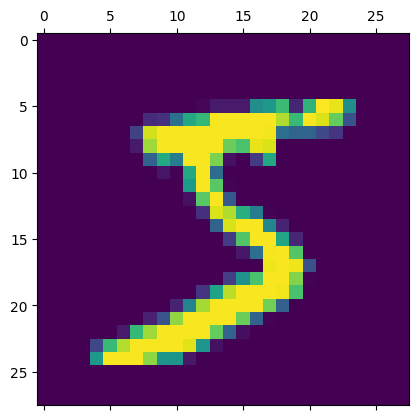

In [ ]:
plt.matshow(X_train[0])

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
flattened_X_train = X_train.reshape(len(X_train),28*28)
flattened_X_train.shape

(60000, 784)

In [ ]:
flattened_X_test = X_test.reshape(len(X_test),28*28)
flattened_X_test.shape

(10000, 784)

In [ ]:
flattened_X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(flattened_X_train,Y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8734 - loss: 0.4493
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9636 - loss: 0.1283
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.0860
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9819 - loss: 0.0614
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9848 - loss: 0.0495


In [ ]:
#Evaluate the model

model.evaluate(flattened_X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9699 - loss: 0.0903


[0.07610227912664413, 0.9764000177383423]

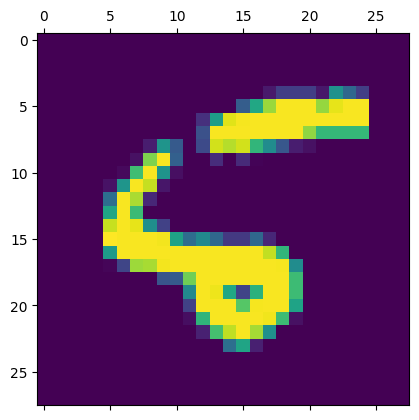

In [ ]:
plt.matshow(X_test[8])

In [ ]:
y_predicted = model.predict(flattened_X_test)
y_predicted[8]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([1.4649988e-06, 1.9308018e-04, 4.1019477e-02, 3.1845530e-03,
       2.1593964e-02, 9.9248689e-01, 9.9514318e-01, 1.0490350e-05,
       8.5198748e-01, 1.5889464e-02], dtype=float32)

In [ ]:
final_answer = np.argmax(y_predicted[8])
final_answer

np.int64(6)

In [ ]:
y_labels = [ np.argmax(n) for n in y_predicted]
y_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [ ]:
cf = tf.math.confusion_matrix(labels=Y_test,predictions=y_labels)
cf

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 965,    0,    1,    1,    0,    3,    4,    0,    4,    2],
       [   0, 1122,    3,    2,    0,    0,    3,    0,    5,    0],
       [   2,    0, 1004,    5,    2,    0,    3,    4,   12,    0],
       [   0,    0,    4,  988,    0,    4,    0,    2,    9,    3],
       [   1,    0,    1,    1,  964,    0,    4,    2,    2,    7],
       [   2,    1,    0,    5,    2,  870,    4,    0,    7,    1],
       [   3,    2,    1,    1,    3,    5,  939,    0,    4,    0],
       [   1,    6,   10,    4,    5,    0,    0,  986,    3,   13],
       [   3,    1,    0,    4,    6,    5,    2,    2,  947,    4],
       [   1,    5,    0,    6,    7,    4,    2,    0,    5,  979]],
      dtype=int32)>

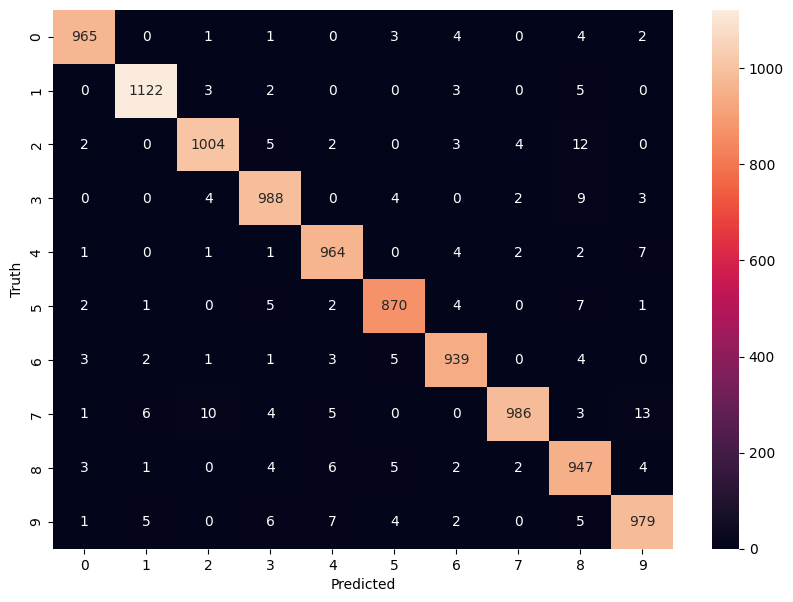

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sn.heatmap(cf, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.show()
